# Temporal Convolutional Neural Network (TCN) for Turbofan Engine RUL Prediction

## Overview

This educational notebook demonstrates how to use a **Temporal Convolutional Neural Network (TCN)** for time series prediction of Remaining Useful Life (RUL) of turbofan engines.

## Learning Objectives

By the end of this notebook, you will:
- Understand how convolutional networks can process time series
- Learn about dilated convolutions for capturing long-range dependencies
- Build a TCN architecture with residual connections
- Compare TCN performance with RNN/LSTM approaches

## What is a Temporal CNN?

**Temporal Convolutional Networks** use 1D convolutions to process sequences, similar to how CNNs process images. TCNs are an alternative to RNNs for sequence modeling.

### Key Concepts:

1. **1D Convolutions**: Slide filters across the time dimension to detect patterns
2. **Dilated Convolutions**: Skip timesteps to capture long-range dependencies efficiently
3. **Residual Connections**: Allow gradients to flow through many layers (like ResNet for images)
4. **Causal Padding**: Ensures predictions only use past information (no future data leakage)

### Advantages:
- **Parallel processing**: Can process entire sequence at once (faster than RNNs)
- **Stable gradients**: No vanishing gradient problem
- **Flexible receptive field**: Dilated convolutions can see far into the past
- **Interpretable**: Can visualize what patterns the filters detect

### When to Use:
- When you need fast training and inference
- Long sequences where RNNs struggle
- When you want parallel processing
- When interpretability of learned patterns is important


## 1. Import Libraries

### Purpose
Import TensorFlow/Keras components for building TCN architecture, including Conv1D layers for temporal convolutions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time  # For measuring training time
warnings.filterwarnings('ignore')

# Configure TensorFlow to use CPU only (avoids CUDA/libdevice issues)
# IMPORTANT: Set this BEFORE importing TensorFlow for it to take effect
# If you still see GPU errors, restart the kernel and run this cell first!
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable GPU, use CPU only
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings

# Deep Learning
import tensorflow as tf

# Aggressively disable GPU and force CPU usage
try:
    # Hide all GPU devices
    tf.config.set_visible_devices([], 'GPU')
    # Set memory growth to prevent GPU allocation
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, False)
except:
    pass

# Force CPU device placement for all operations
tf.config.set_soft_device_placement(True)
with tf.device('/CPU:0'):
    # This ensures CPU is used by default
    pass

from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Input, Add, Activation, BatchNormalization, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

# Verify GPU is disabled
print(f"\n📊 TensorFlow Device Configuration:")
print(f"   Available GPUs: {len(tf.config.list_physical_devices('GPU'))}")
print(f"   Available CPUs: {len(tf.config.list_physical_devices('CPU'))}")
if len(tf.config.list_physical_devices('GPU')) == 0:
    print("   ✅ GPU successfully disabled - using CPU only")
else:
    print("   ⚠️  WARNING: GPU still detected! Please restart kernel and run this cell first.")


Libraries imported successfully!
TensorFlow version: 2.20.0

📊 TensorFlow Device Configuration:
   Available GPUs: 0
   Available CPUs: 1
   ✅ GPU successfully disabled - using CPU only


2026-01-17 22:46:45.208763: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 2. Load and Prepare Data

### Purpose
Load the dataset. TCNs process sequences similarly to RNNs, but use convolution operations instead of recurrence.


In [2]:
# Define data path
data_path = Path('../dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names with actual field names
op_settings = ['Altitude', 'Mach', 'TRA']
sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
           'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data"""
    train_file = data_path / f'train_{dataset}.csv'
    test_file = data_path / f'test_{dataset}.csv'
    rul_file = data_path / f'RUL_{dataset}.csv'
    
    # CSV files already have headers, so no need for sep, header=None, or names
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    rul_df = pd.read_csv(rul_file)
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """Calculate RUL for training data"""
    df = df.copy()
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load data
train_df, test_df, rul_df = load_data('FD001')
train_df = calculate_rul_train(train_df)

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Number of engines in training: {train_df['unit'].nunique()}")
print(f"Number of engines in test: {test_df['unit'].nunique()}")


Training data shape: (20631, 27)
Test data shape: (13096, 26)
Number of engines in training: 100
Number of engines in test: 100


## 3. Create Time Series Sequences

### Purpose
Create sequences for TCN processing. TCNs can process these sequences in parallel (unlike RNNs which process sequentially), making training faster.


In [3]:
def create_sequences(data, sequence_length=30):
    """Create sequences for time series prediction"""
    sequences = []
    targets = []
    
    # Select features (using actual field names)
    op_settings = ['Altitude', 'Mach', 'TRA']
    sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
               'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
    feature_cols = op_settings + sensors
    
    for unit_id in data['unit'].unique():
        unit_data = data[data['unit'] == unit_id].sort_values('time')
        unit_features = unit_data[feature_cols].values
        unit_rul = unit_data['RUL'].values
        
        # Create sequences
        for i in range(len(unit_data) - sequence_length + 1):
            sequences.append(unit_features[i:i+sequence_length])
            targets.append(unit_rul[i+sequence_length-1])
    
    return np.array(sequences), np.array(targets)

# Create sequences
sequence_length = 30
X_train_seq, y_train_seq = create_sequences(train_df, sequence_length)

# For test data
def create_test_sequences(data, sequence_length=30):
    """Create test sequences"""
    sequences = []
    op_settings = ['Altitude', 'Mach', 'TRA']
    sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
               'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
    feature_cols = op_settings + sensors
    
    for unit_id in sorted(data['unit'].unique()):
        unit_data = data[data['unit'] == unit_id].sort_values('time')
        unit_features = unit_data[feature_cols].values
        
        if len(unit_features) >= sequence_length:
            sequences.append(unit_features[-sequence_length:])
        else:
            padding = np.zeros((sequence_length - len(unit_features), len(feature_cols)))
            sequences.append(np.vstack([padding, unit_features]))
    
    return np.array(sequences)

X_test_seq = create_test_sequences(test_df, sequence_length)
y_test = rul_df['RUL'].values

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")


Training sequences shape: (17731, 30, 24)
Test sequences shape: (100, 30, 24)


## 4. Data Normalization

### Purpose
Normalize data for TCN training. Convolutional layers are sensitive to input scale, so normalization is essential.


In [4]:
# Normalize features
feature_scaler = MinMaxScaler()
n_samples, n_timesteps, n_features = X_train_seq.shape
X_train_reshaped = X_train_seq.reshape(-1, n_features)
X_train_scaled = feature_scaler.fit_transform(X_train_reshaped)
X_train_seq_scaled = X_train_scaled.reshape(n_samples, n_timesteps, n_features)

# Normalize test data
X_test_reshaped = X_test_seq.reshape(-1, n_features)
X_test_scaled = feature_scaler.transform(X_test_reshaped)
X_test_seq_scaled = X_test_scaled.reshape(X_test_seq.shape)

# Normalize targets
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train_seq.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten()

print("Data normalized successfully!")


Data normalized successfully!


## 5. Build Temporal CNN Model

### Purpose
Construct a TCN architecture with dilated convolutions and residual connections.

### Architecture Components:

1. **Temporal Blocks**: 
   - Two 1D convolutions with dilation
   - Batch normalization for stable training
   - Residual connection (adds input to output)
   - Helps with gradient flow and learning

2. **Dilated Convolutions**:
   - Dilation rate 1: Looks at adjacent timesteps
   - Dilation rate 2: Looks at every 2nd timestep (wider view)
   - Dilation rate 4: Looks at every 4th timestep (even wider)
   - Dilation rate 8: Looks at every 8th timestep (very wide view)
   - **Exponential growth**: Each block doubles the receptive field

3. **Residual Connections**:
   - Allow information to skip layers
   - Help with training deep networks
   - Enable learning of identity mappings

### Why This Architecture Works:
- **Multi-scale patterns**: Different dilation rates capture patterns at different time scales
- **Long-range dependencies**: High dilation rates can see far into the past
- **Stable training**: Residual connections prevent vanishing gradients


In [5]:
def temporal_block(x, filters, kernel_size, dilation_rate):
    """Temporal block with dilated convolution and residual connection"""
    # Main path
    conv1 = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='same')(x)
    bn1 = BatchNormalization()(conv1)
    act1 = Activation('relu')(bn1)
    dropout1 = Dropout(0.2)(act1)
    
    conv2 = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='same')(dropout1)
    bn2 = BatchNormalization()(conv2)
    act2 = Activation('relu')(bn2)
    dropout2 = Dropout(0.2)(act2)
    
    # Residual connection
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    
    out = Add()([x, dropout2])
    return Activation('relu')(out)

def build_tcn_model(sequence_length, n_features):
    """Build Temporal CNN model"""
    # Force CPU device placement to avoid GPU errors
    with tf.device('/CPU:0'):
        inputs = Input(shape=(sequence_length, n_features))
        
        # Initial convolution
        x = Conv1D(64, 3, padding='same')(inputs)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        
        # Temporal blocks with increasing dilation rates
        x = temporal_block(x, 64, 3, dilation_rate=1)
        x = temporal_block(x, 64, 3, dilation_rate=2)
        x = temporal_block(x, 64, 3, dilation_rate=4)
        x = temporal_block(x, 64, 3, dilation_rate=8)
        
        # Global pooling
        x = GlobalMaxPooling1D()(x)
        
        # Dense layers
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.3)(x)
        x = Dense(32, activation='relu')(x)
        outputs = Dense(1)(x)
        
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Build model
n_features = X_train_seq_scaled.shape[2]
model = build_tcn_model(sequence_length, n_features)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      4,672 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ activation[0][0], │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 30, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 64)    │     12,352 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 64)    │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 112,065 (437.75 KB)

 Trainable params: 110,913 (433.25 KB)

 Non-trainable params: 1,152 (4.50 KB)

## 6. Train Model

### Purpose
Train the TCN model. TCNs typically train faster than RNNs because:
- Convolutions can be parallelized
- No sequential dependency (unlike RNNs)
- Can process batches more efficiently


In [6]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train model
history = model.fit(
    X_train_seq_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.2974 - mae: 0.2885 - val_loss: 0.0458 - val_mae: 0.1531 - learning_rate: 0.0010
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0243 - mae: 0.1182 - val_loss: 0.0364 - val_mae: 0.1390 - learning_rate: 0.0010
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0187 - mae: 0.1032 - val_loss: 0.0284 - val_mae: 0.1249 - learning_rate: 0.0010
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0167 - mae: 0.0970 - val_loss: 0.0310 - val_mae: 0.1303 - learning_rate: 0.0010
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0153 - mae: 0.0920 - val_loss: 0.0309 - val_mae: 0.1287 - learning_rate: 0.0010
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0143 - mae: 0.0880 - val_loss: 0.0307 - val_mae: 0.1291 - learning_rate: 0.0010
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0135 - mae: 0.0857 - val_loss: 0.0323 - val_mae: 0.1303 - learning_rate: 0.001

## 7. Evaluate Model

### Purpose
Evaluate TCN performance. Compare with RNN/LSTM to see if convolutional approach provides advantages.


In [7]:
# Predictions
y_train_pred_scaled = model.predict(X_train_seq_scaled, verbose=0)
y_test_pred_scaled = model.predict(X_test_seq_scaled, verbose=0)

# Inverse transform
y_train_pred = target_scaler.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred = target_scaler.inverse_transform(y_test_pred_scaled).flatten()

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train_seq, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train_seq, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train_seq, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("="*60)
print("Temporal CNN Model Performance")
print("="*60)
print(f"\nTraining Metrics:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")
print(f"\nTest Metrics:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")


Temporal CNN Model Performance

Training Metrics:
  RMSE: 40.3180
  MAE:  31.1078
  R²:   0.5760

Test Metrics:
  RMSE: 28.0767
  MAE:  23.6174
  R²:   0.5435


## 8. Visualizations

### Purpose
Visualize TCN training and predictions. Compare training speed and final performance with RNN-based approaches.


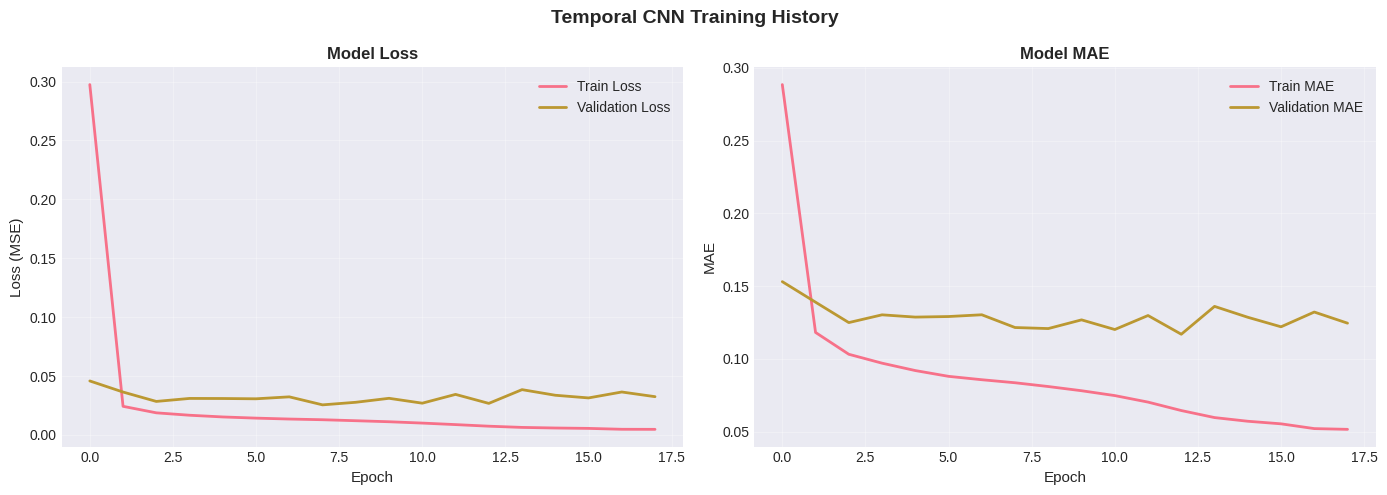

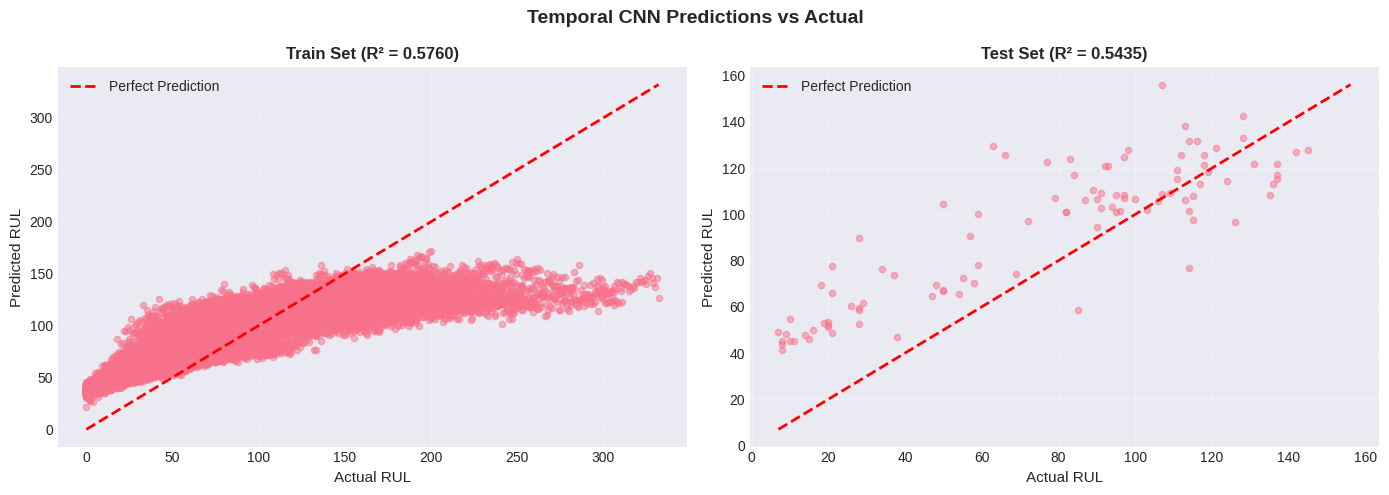

In [8]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Temporal CNN Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('Model MAE', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Temporal CNN Predictions vs Actual', fontsize=14, fontweight='bold')

# Training set
axes[0].scatter(y_train_seq, y_train_pred, alpha=0.5, s=20)
min_val = min(min(y_train_seq), min(y_train_pred))
max_val = max(max(y_train_seq), max(y_train_pred))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL', fontsize=11)
axes[0].set_ylabel('Predicted RUL', fontsize=11)
axes[0].set_title(f'Train Set (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=20)
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual RUL', fontsize=11)
axes[1].set_ylabel('Predicted RUL', fontsize=11)
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7.5. Parameter Tuning with K-Fold Cross-Validation

### Purpose
Improve Temporal CNN model performance by finding the best hyperparameters using cross-validation.

### Hyperparameters We'll Tune for Temporal CNN:

- **Number of filters**: Conv1D filters (32, 64, 128)
- **Kernel size**: Convolution window size (3, 5, 7)
- **Dilation rates**: Temporal block dilation (1, 2, 4, 8)
- **Learning rate**: How fast the model learns (0.001, 0.0001)
- **Batch size**: Samples per update (16, 32, 64)
- **Dropout rate**: Regularization strength (0.2, 0.3, 0.4)

In [ ]:
# Import additional libraries for cross-validation
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.metrics import mean_squared_error, r2_score

print("✅ Cross-validation libraries imported!")

In [ ]:
def evaluate_tcn_hyperparameters(X, y, param_combinations, n_splits=3, epochs=20, verbose=0):
    """Evaluate Temporal CNN hyperparameters with cross-validation"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    
    print(f"🔍 Evaluating {len(param_combinations)} TCN parameter combinations...")
    print(f"   Using {n_splits}-fold cross-validation")
    print("=" * 70)
    
    for idx, params in enumerate(param_combinations, 1):
        print(f"\n[{idx}/{len(param_combinations)}] Testing: {params}")
        fold_scores = []
        fold_r2_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
            if verbose > 0:
                print(f"  Fold {fold}/{n_splits}...", end=" ")
            
            X_train_fold = X[train_idx]
            y_train_fold = y[train_idx]
            X_val_fold = X[val_idx]
            y_val_fold = y[val_idx]
            
            with tf.device('/CPU:0'):
                inputs = Input(shape=(X.shape[1], X.shape[2]))
                x = Conv1D(params['filters'], params['kernel_size'], padding='same')(inputs)
                x = BatchNormalization()(x)
                x = Activation('relu')(x)
                
                # Temporal blocks
                for dilation in params['dilations']:
                    x = temporal_block(x, params['filters'], params['kernel_size'], dilation_rate=dilation)
                
                x = GlobalMaxPooling1D()(x)
                x = Dense(64, activation='relu')(x)
                x = Dropout(params['dropout'])(x)
                x = Dense(32, activation='relu')(x)
                outputs = Dense(1)(x)
                
                model = Model(inputs, outputs)
                model.compile(optimizer=Adam(learning_rate=params['learning_rate']), 
                            loss='mse', metrics=['mae'])
            
            model.fit(X_train_fold, y_train_fold, epochs=epochs, batch_size=params['batch_size'],
                     validation_data=(X_val_fold, y_val_fold), verbose=0,
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
            
            y_pred_fold = model.predict(X_val_fold, verbose=0)
            rmse_fold = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
            r2_fold = r2_score(y_val_fold, y_pred_fold)
            
            fold_scores.append(rmse_fold)
            fold_r2_scores.append(r2_fold)
            
            if verbose > 0:
                print(f"RMSE: {rmse_fold:.4f}, R²: {r2_fold:.4f}")
        
        avg_rmse = np.mean(fold_scores)
        std_rmse = np.std(fold_scores)
        avg_r2 = np.mean(fold_r2_scores)
        std_r2 = np.std(fold_r2_scores)
        
        results.append({
            'params': params,
            'avg_rmse': avg_rmse,
            'std_rmse': std_rmse,
            'avg_r2': avg_r2,
            'std_r2': std_r2
        })
        
        print(f"  ✅ Average RMSE: {avg_rmse:.4f} (±{std_rmse:.4f})")
        print(f"     Average R²: {avg_r2:.4f} (±{std_r2:.4f})")
    
    return results

print("✅ TCN hyperparameter evaluation function created!")

In [ ]:
# Define TCN hyperparameter combinations
param_combinations_tcn = [
    {'filters': 32, 'kernel_size': 3, 'dilations': [1, 2, 4], 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2},
    {'filters': 64, 'kernel_size': 3, 'dilations': [1, 2, 4, 8], 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2},
    {'filters': 128, 'kernel_size': 3, 'dilations': [1, 2, 4, 8], 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2},
    {'filters': 64, 'kernel_size': 5, 'dilations': [1, 2, 4, 8], 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2},
    {'filters': 64, 'kernel_size': 3, 'dilations': [1, 2, 4, 8], 'learning_rate': 0.0001, 'batch_size': 32, 'dropout': 0.2},
    {'filters': 64, 'kernel_size': 3, 'dilations': [1, 2, 4, 8], 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.3},
]

print(f"📋 Defined {len(param_combinations_tcn)} TCN hyperparameter combinations")

### Run Cross-Validation for Temporal CNN

**Note**: This will take time. Using 3-fold CV with fewer epochs for speed.

In [ ]:
# Run TCN hyperparameter tuning
print("🚀 Starting TCN Hyperparameter Tuning...")
print("⚠️  This may take 15-25 minutes...")
print("=" * 70)

start_time = time.time()
tuning_results_tcn = evaluate_tcn_hyperparameters(
    X_train_seq_scaled, y_train_scaled,
    param_combinations_tcn, n_splits=3, epochs=20, verbose=1
)
tuning_time = time.time() - start_time

print(f"\n✅ TCN tuning completed in {tuning_time/60:.1f} minutes!")

# Find best
best_result_tcn = max(tuning_results_tcn, key=lambda x: x['avg_r2'])
best_params_tcn = best_result_tcn['params']

print(f"\n🏆 Best TCN Parameters:")
print(f"   Filters: {best_params_tcn['filters']}, Kernel: {best_params_tcn['kernel_size']}")
print(f"   Learning Rate: {best_params_tcn['learning_rate']}, Dropout: {best_params_tcn['dropout']}")
print(f"   Best CV R²: {best_result_tcn['avg_r2']:.4f}")